In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as   mcolors
from datataking import search_datadict_miyamura
from scipy import interpolate
from Analysis import WaveformAnalysis, WaveformAnalysisMulti, fourier_tr_padding, lowpass, start_stop#, probe_resonator_fit

In [3]:
cd = "CDY155"
data_path = f"D:\\K_Sunada\\result\\{cd}"

readout_lo_freq = 10.380

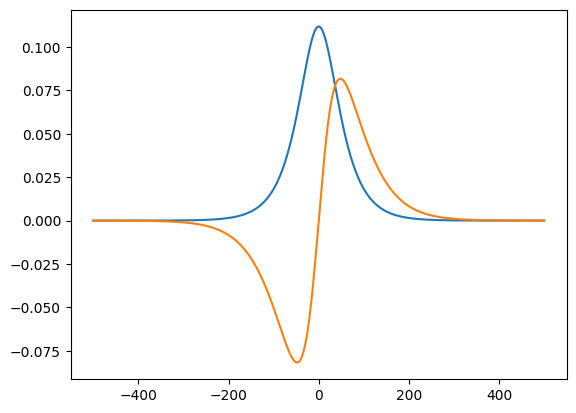

In [4]:
t = np.linspace(-500, 500, 1001)
kappa = 5e-2

xi_0 = (kappa/4)**0.5 / np.cosh(kappa*t/2)
xi_1 = (3*kappa**3/(4*np.pi**2))**0.5 / np.cosh(kappa*t/2)*t

plt.plot(t, xi_0)
plt.plot(t, xi_1)

In [5]:
from scipy.integrate import quad

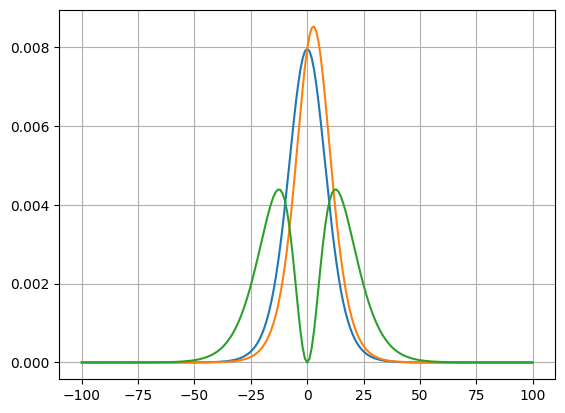

In [15]:
time = np.linspace(-100, 100, 201)
center = 0
const = 0.1

def squared_sech(x):
    def func(var):
        return 1/np.cosh(const*var)**2
    norm_func = func(x)/quad(func,time[0], time[-1])[0]
    return norm_func

def squared_anti_sech(x):
    def func(var):
        return (var/np.cosh(const*var))**2
    norm_func = func(x)/quad(func, time[0], time[-1])[0]
    return norm_func

gamma_t = []
for t in time:
    top = squared_sech(t-center) #(const/2)/(np.cosh(const*(t-center)))**2
    bottom = 1- quad(squared_sech, center, t)[0]** 2
    gamma_t = np.append(gamma_t, top/bottom/2/np.pi)

gamma_t1 = []
for t in time:
    top = (const/2)/(np.cosh(const*(t-center)))**2
    bottom = 1-(1/2)*(np.tanh(const*(t-center))+np.tanh(const*center))
    gamma_t1 = np.append(gamma_t1, top/bottom/2/np.pi)


gamma_t_anti = []
for t in time:
    top = squared_anti_sech(t-center)
    bottom = 1- quad(squared_anti_sech, center, t)[0]** 2
    gamma_t_anti = np.append(gamma_t_anti, top/bottom/2/np.pi)

plt.plot(time, gamma_t)
plt.plot(time, gamma_t1)
plt.plot(time, gamma_t_anti)
plt.grid()

In [12]:
name_dict = dict(
    # data1 = dict(amp=0.1, date="2023-12-27", acquire_time="144548", params=dict(fit_start=30, fp=0.01, fs=0.05, gpass=1, gstop=90)), 
    data2 = dict(amp=0.2, date="2024-02-20", acquire_time="151910", params=dict(fit_start=100, fp=0.01, fs=0.05, gpass=1, gstop=90)), 
    # data3 = dict(amp=0.3, date="2023-12-27", acquire_time="003842", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    data4 = dict(amp=0.4, date="2024-02-20", acquire_time="164056", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data5 = dict(amp=0.5, date="2023-12-27", acquire_time="003054", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    data6 = dict(amp=0.6, date="2024-02-20", acquire_time="171443", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    data7 = dict(amp=0.7, date="2024-02-21", acquire_time="113108", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    data8 = dict(amp=0.8, date="2024-02-20", acquire_time="174643", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data85 = dict(amp=0.85, date="2023-12-27", acquire_time="223440", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    data9 = dict(amp=0.9, date="2024-02-21", acquire_time="120117", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    data10 = dict(amp=1.0, date="2024-02-20", acquire_time="181756", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    data11 = dict(amp=1.1, date="2024-02-21", acquire_time="123003", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
)

# Generating Control Pulses

In [13]:
dataobj = WaveformAnalysisMulti(name_dict, data_path)
dataobj.generate_results(readout_lo_freq)
# 2024-2-20 janakute 2024-02-20 (miyamura)

0.2 2024-02-20 151910
0.4 2024-02-20 164056
0.6 2024-02-20 171443
0.7 2024-02-21 113108
0.8 2024-02-20 174643
0.9 2024-02-21 120117
1.0 2024-02-20 181756
1.1 2024-02-21 123003


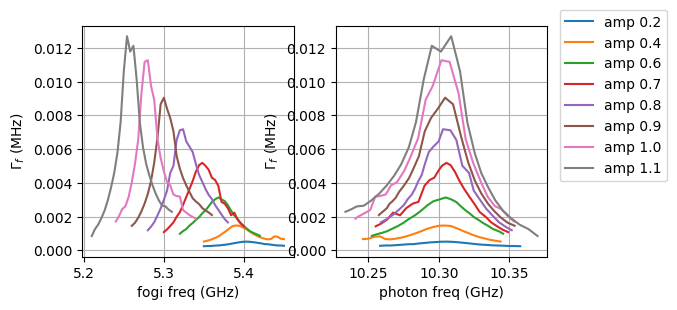

{'a0': 0, 'a2': 0.00998891692027537, 'a4': 0.0003515541359651042, 'a6': 3.4416913763379853e-13, 'a8': 3.816280624846513e-12, 'a10': 4.624967075983477e-12}


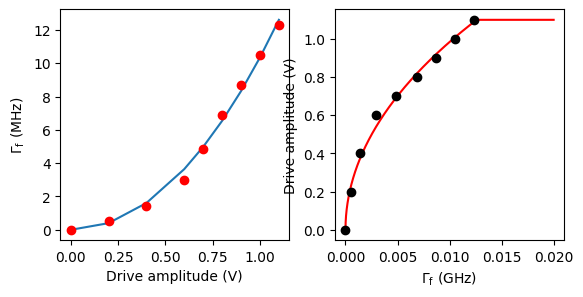

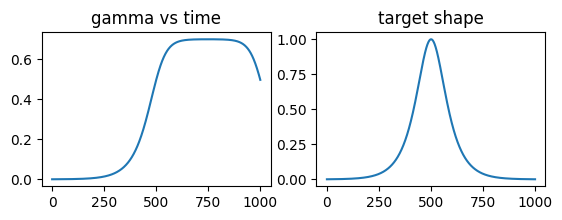

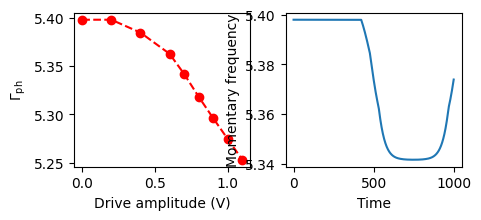

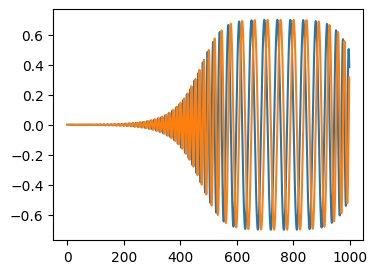

In [14]:
form = "sech"
const = 2.5e-3 * 2 * np.pi
duration = 1000
target_freq = 10.31

# plot decay rates
dataobj.plot_decayrates()

control_pulse = dataobj.generate_control_pulse(5.32, target_freq, duration, const=const, form=form)

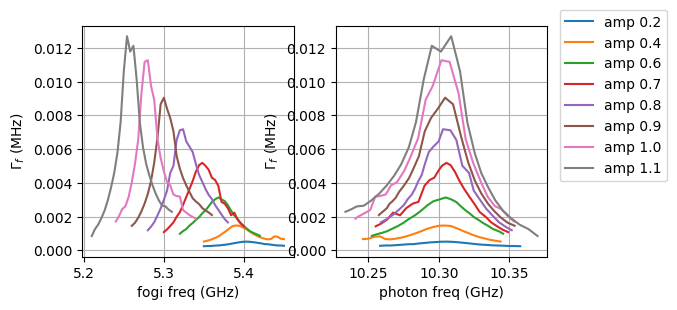

{'a0': 0, 'a2': 0.00998891692027537, 'a4': 0.0003515541359651042, 'a6': 3.4416913763379853e-13, 'a8': 3.816280624846513e-12, 'a10': 4.624967075983477e-12}


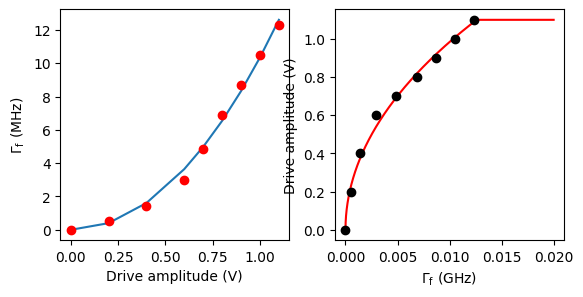

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240 241 242 243 244 245 24

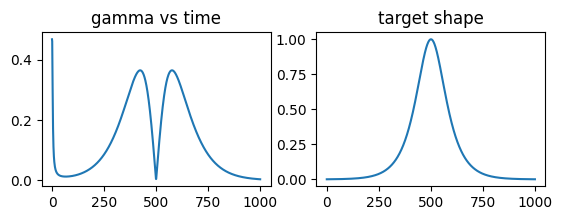

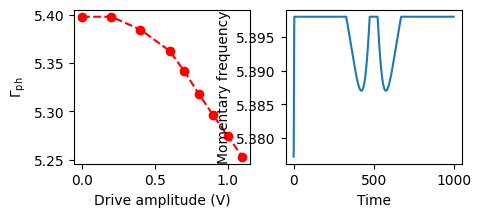

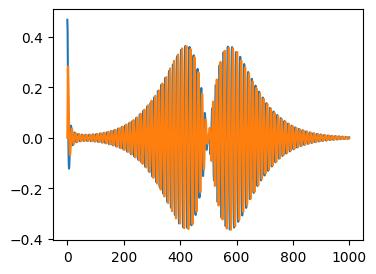

In [9]:
form = "anti_sech"
const = 2.5e-3 * 2 * np.pi
duration = 1000
target_freq = 10.31

# plot decay rates
dataobj.plot_decayrates()

control_pulse = dataobj.generate_control_pulse(5.32, target_freq, duration, const=const, form=form)

## test

In [10]:
# check
import lmfit as lmf
def decay(t, gamma, A, off):
    return A * np.exp(-(t-t[0])*gamma) + off
def guess_params_decay(data, t):
    off_ini = np.mean(data[-5:])#data[-1]
    moving_average = np.convolve(data, np.ones(25)/25, mode="valid")
    A_ini = moving_average[0]#np.sign(data[0]-data[-1])*(max(data) - min(data))
    par_ini = {
        'gamma': abs((moving_average[0]-moving_average[5])/(t[0]-t[5]))/A_ini,#-(data[0]-data[2])/(t[0]-t[2]) ,
        'A': A_ini,'off': off_ini
    }
    par_max = {'gamma': 1,'A': 2*A_ini,'off': 5*np.abs(off_ini)}
    par_min = {'gamma': 0,'A': 0.5*A_ini,'off': -5*np.abs(off_ini)}
    par_vary = {'gamma': True,'A': True,'off': True,}
    return par_ini,par_max,par_min,par_vary
def decay_fit(data, t):
    decay_model = lmf.Model(decay)
    params_decay = decay_model.make_params()
    decay_par_ini,decay_par_max,decay_par_min,decay_par_vary=guess_params_decay(data,t)
    for name in params_decay:
        params_decay[name].set(
            value=decay_par_ini[name],  # 初期値
            min=decay_par_min[name],  # 下限値
            max=decay_par_max[name],  # 上限値
            vary=decay_par_vary[name] # パラメータを動かすかどうか
        )
    result=decay_model.fit(data, t=t, params=params_decay, method='leastsq')
    delm = result.eval_uncertainty(sigma=1)
    return result

_, datadict = search_datadict_miyamura(data_path, since="2023-10-10", acquire_time="061732")
waveforms = datadict["waveform"]["values"]
time = np.unique(datadict["time"]["values"])
freqs = np.unique(datadict["fogi_frequency"]["values"])
decay_rates, stderrs, _ = [], [], []
_to_rf = lambda if_freq:10.633 + if_freq
for i, waveform in enumerate(waveforms):
    freq_fft, fourier = fourier_tr_padding(time, waveform)
    freq_fft, fourier = start_stop(freq_fft, fourier, 0, freq_fft[-1])
    photon_frequency = _to_rf(freq_fft)
    if 1: photon_if_freq = 10.18 - photon_frequency[np.argmax(np.abs(fourier))]
    # else: photon_if_freq = lo_freq + photon_frequency[np.argmax(np.abs(fourier))]
    signal = 2 * lowpass(time, 
                            waveform * np.exp(2j * np.pi * photon_if_freq * time), 
                            0.01, 0.04, 1, 90
                            )
    envelope = np.abs(signal)
    t, env = start_stop(time, envelope, 20, time[-1])
    result = decay_fit(env, t)
    decay_rates.append(result.params.valuesdict()["gamma"] /2/np.pi)
    stderrs.append(result.result.params["gamma"].stderr / 2 / np.pi)
    plt.figure(figsize=(4, 2))
    plt.plot(t, env, "ko")
    plt.plot(t, result.best_fit)
    plt.show()

    

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'D:\\K_Sunada\\result\\CDY155\\2023-10-10'

## save

In [ ]:
# save control pulse
from plottr.data.datadict_storage import DataDict, DDH5Writer
import time as T

for target_freq in [10.33]:
    control_pulse = dataobj.generate_control_pulse(5.32, target_freq, duration, const=const, form=form, plot=False)
    note = f"""
    form : {form}
    const : {const / 2 / np.pi}
    duration : {duration}
    target frequency : {target_freq} GHz
    """

    data = DataDict(
        time=dict(unit="ns"),
        control_pulse=dict(axes=["time"]),
    )
    data.validate()

    with DDH5Writer(data, "D:\\K_Sunada\\result\\control_pulses", name="Control_Pulse") as writer:
        writer.add_tag(["control_pulse", cd])
        writer.save_text("target_shape.md", note)
        writer.add_data(
            time=np.arange(len(control_pulse)),
            control_pulse=control_pulse,
        )
    T.sleep(1)

{'a0': 0, 'a2': 0.004102115710638676, 'a4': 7.66053886991358e-13, 'a6': 4.375166895442817e-12, 'a8': 2.2315482794965646e-12, 'a10': 1.3284928712664623e-12}


# Photon shaping analysis

In [ ]:
from Analysis import (
    fourier_tr_padding, start_stop, lowpass, demodulate, load_note
)
from scipy import interpolate, optimize

const = 2.5e-3 * 2 * np.pi
result_dict = dict(
    data0 = dict(target_freq=10.29, date="2024-02-22", acquire_time="105928"),
    data1 = dict(target_freq=10.30, date="2024-02-22", acquire_time="110618"),
    data2 = dict(target_freq=10.31, date="2024-02-22", acquire_time="111308"),
    data3 = dict(target_freq=10.32, date="2024-02-22", acquire_time="111957"),
    data4 = dict(target_freq=10.33, date="2024-02-22", acquire_time="112646"),
)

def fit_waveform(time, data, x0=[2e-3,600], get_center=False, curve='gaussian', **kwargs):
    if curve=='gaussian':
        func = lambda x: x[0]*np.exp(-((time-x[1])/kwargs['sigma'])**2/2)
        cost_func = lambda x: np.linalg.norm(x[0]*np.exp(-((time-x[1])/kwargs['sigma'])**2/2) - data)
    elif curve=='sech':
        func = lambda x: x[0]/np.cosh(kwargs['kappa']*(time-x[1]))
        cost_func = lambda x: np.linalg.norm(x[0]/np.cosh(kwargs['kappa']*(time-x[1])) - data)
    elif curve=="raisedcos":
        func = lambda x: x[0]*np.sin(np.pi*(time-x[1])/kwargs['T'])**2*(time<=kwargs['T']+x[1])*(x[1]<=time)
        cost_func = lambda x: np.linalg.norm(x[0]*np.sin(np.pi*(time-x[1])/kwargs['T'])**2*(time<=kwargs['T']+x[1])*(x[1]<=time) - data)
    best_x = optimize.minimize(cost_func, x0=x0,method='Nelder-Mead',)
    # print(best_x)
    # print(f"center:{best_x.x}")
    if get_center==True:
        return best_x.x, func(best_x.x)
    return func(best_x.x)

def IQ_sym_(wave,time,start=0,stop=3000):
    wave_rev = np.flip(wave)
    norm=np.sum(np.abs(wave)**2)**2
    m=0
    c=[]
    for i in range(len(wave)):
        wave_rev_i = np.roll(wave_rev, i)
        mult = wave*wave_rev_i
        mult_sum=np.sum(mult)
        cand = np.abs(mult_sum)**2
        c.append(cand/norm)
        if m<cand:
            m=cand
    # plt.plot(np.arange(len(wave)), c)
    return m/norm

def target_overlap(wave, time):
    wave_rev = np.flip(wave)
    target = 1 / np.cosh(const * (time-time[-1]/2))
    norm = np.sum(np.abs(wave)**2) * (time[1] - time[0])
    norm_target  =np.sum(np.abs(target)**2) * (time[1] - time[0])
    m=0 ;c=[]
    for i in range(len(wave)):
        wave_rev_i = np.roll(wave_rev, i)
        mult = target*wave_rev_i
        mult_sum=np.sum(mult) * (time[1] - time[0])
        cand = np.abs(mult_sum)**2
        c.append(cand/norm)
        if m<cand:
            m=cand
    return m / norm / norm_target

symmetry 0.9718726386208024, overlap 0.8496939366726806
symmetry 0.9171941408406479, overlap 0.893983754677914
symmetry 0.9403129761355145, overlap 0.8564440554678612
symmetry 0.880477361750975, overlap 0.8845498130597608
symmetry 0.9341430352400347, overlap 0.9041290395170484


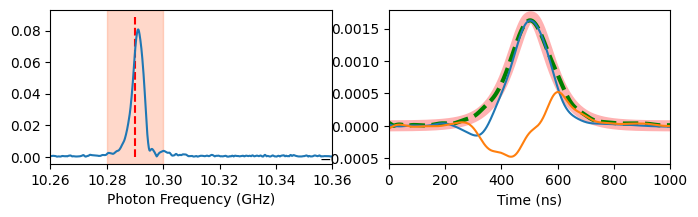

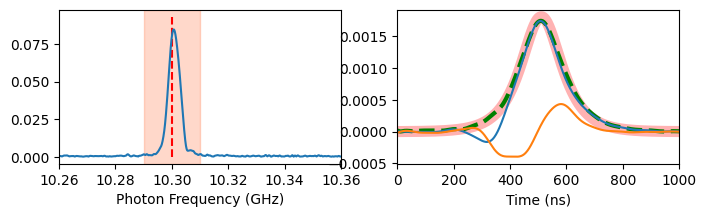

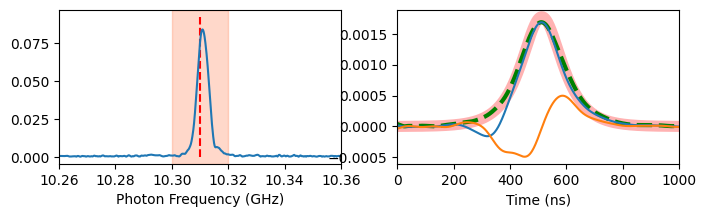

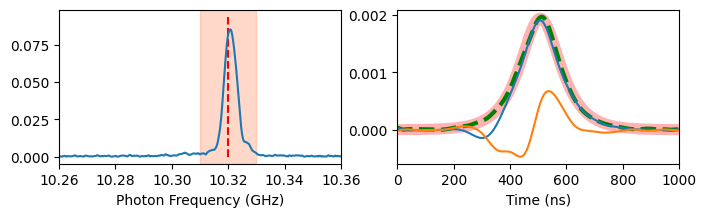

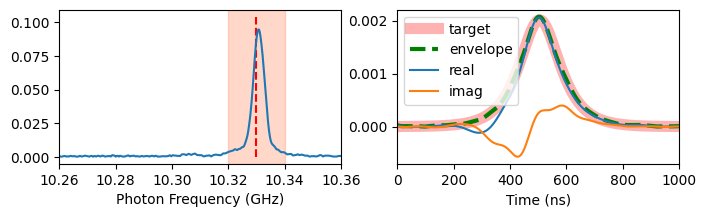

In [ ]:
passing_band = 0.01
duration=1500
cd = "CDY155"
data_path = f"D:\\K_Sunada\\result\\{cd}"

for k, v in result_dict.items():
    fig = plt.figure(figsize=(8, 2))
    ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    target_freq = v["target_freq"]
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    time = datadict["time"]["values"].ravel()
    waveform = datadict["waveform"]["values"].ravel()
    time, waveform = start_stop(time, waveform, 0, duration)
    phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    # print(readout_lo_freq-target_freq)
    xfft, fourier = fourier_tr_padding(time, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    ax.vlines(target_freq, 0, max(np.abs(fourier))*1.1, color="r", ls="--")
    ax.plot(photon_freq, np.abs(fourier))
    ax.axvspan(target_freq-passing_band, target_freq+passing_band, color="coral", alpha=0.3)
    ax.set_xlim(10.26, 10.36)
    ax.set_xlabel("Photon Frequency (GHz)")

    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        passing_band, 0.03, 0.1, 90) * np.exp(-1j*phase)
    res = fit_waveform(time, np.abs(signal), curve="sech", kappa=const)
    ax2.plot(time, res, "r-", lw=8, label="target", alpha=0.3)
    ax2.plot(time, np.abs(signal), "g--", lw=3, label="envelope")
    ax2.plot(time, signal.real, label="real")
    ax2.plot(time, signal.imag, label="imag")
    ax2.set_xlabel("Time (ns)")
    ax2.set_xlim(0, 1000)
    print(f"symmetry {IQ_sym_(signal, time)}, overlap {target_overlap(signal, time)}")
plt.legend()


In [ ]:
def watt_dbm(watt):
    return 10*np.log10(watt*1e3)

def dbm_watt(dBm):
    return (10**(dBm/10))*1e-3

In [ ]:
from scipy.constants import *

In [ ]:
def photon_number(pulse, freq, atten_fixed, atten_fridge, atten_RT, sample_rate, P_vna):
    #pulse: [x, y, env], atten: dBm, samplerate: s, P_vna: W (AWG amp=1.0)
    x = pulse[0]
    y = pulse[2] #env

    atten_W = 10**((atten_fixed + atten_fridge + atten_RT)/10)
    ene = 0
    for t in range(int(len(x)/sample_rate*1e-9)):
        ene = ene + (y[2*t]**2)*sample_rate
    print(watt_dbm(P_vna*atten_W))

    return ene * P_vna * atten_W/ (2*np.pi*hbar*freq)

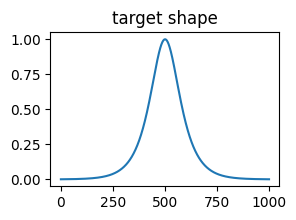

In [ ]:
time = np.linspace(0, 999, 1000)
duration = 1000
fig = plt.figure(figsize = (6.5, 2))
ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(time, 1/np.cosh(const * (time - duration/2)))#*np.cos())
ax2.set_title('target shape')
plt.show()

10290000000.0
-120.5493100353141


1.480983039842308

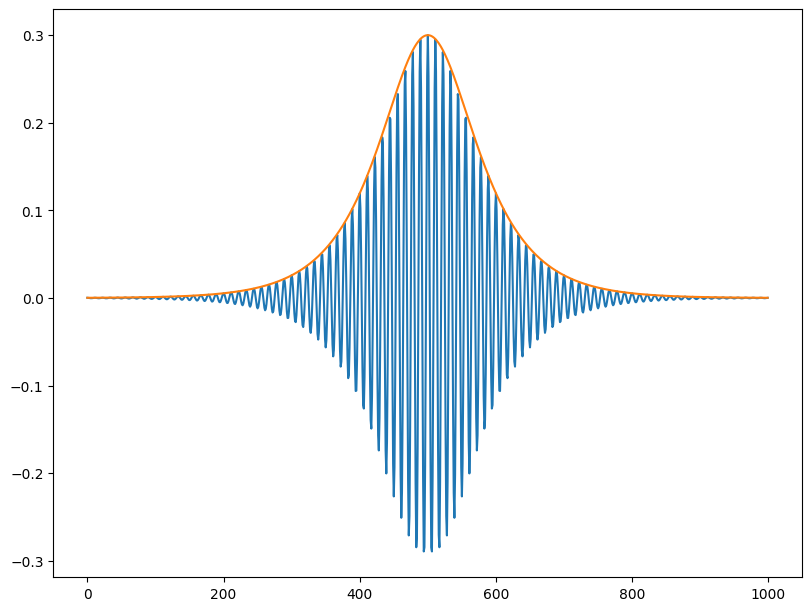

In [ ]:
ph_if = readout_lo_freq - np.array([10.29e9, 10.30e9, 10.31e9, 10.32e9, 10.33e9]) 
id = 0

x = np.linspace(0, 999, 1000)
duration = len(x)
y_env = 1/np.cosh(const * (x - duration/2))
y = 1/np.cosh(const * (x - duration/2))*np.cos(2*np.pi* ph_if[id]*x*1e-9)
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.plot(x, y*0.3)
plt.plot(x, y_env*0.3)

y_env = y_env*0.3
pulse = [x, y, y_env]
readout_lo_freq = 10.38e9
rf_freq = readout_lo_freq-ph_if[id]
print(rf_freq)
atten_fixed =  -52.5
atten_fridge = -20
atten_RT = -30
sample_rate = 2e-9
P_vna = 1.567e-5
photon_number(pulse, rf_freq, atten_fixed, atten_fridge, atten_RT, sample_rate,P_vna)

In [ ]:
amp_0 = [0.0135, 0.0247, 0.0349, 0.0427, 0.0493]

Phase subtraction

94 2024-02-22T
93 2024-02-22T
94 2024-02-22T
94 2024-02-22T
94 2024-02-22T


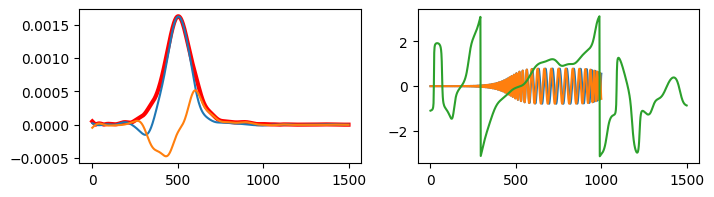

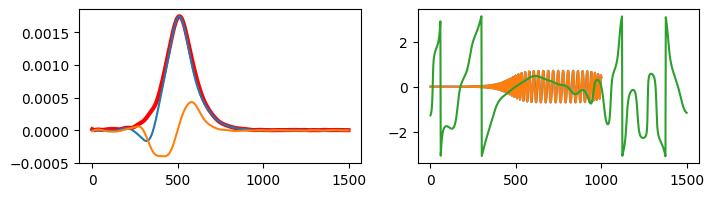

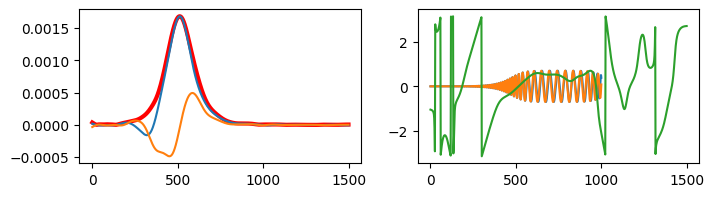

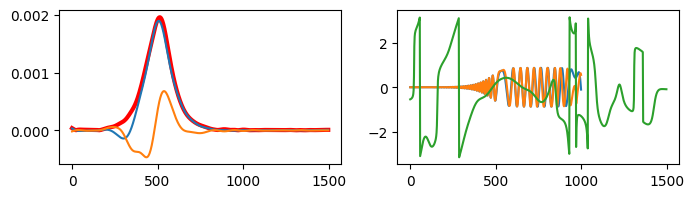

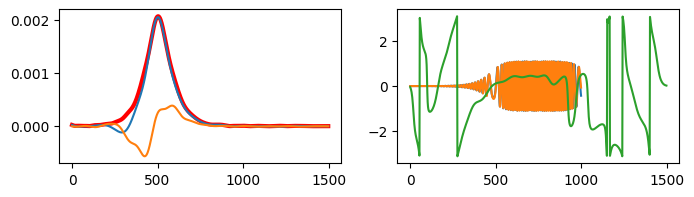

In [ ]:
import time as T
for k, v in result_dict.items():
    fig = plt.figure(figsize=(8, 2))
    ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    target_freq = v["target_freq"]
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    time = datadict["time"]["values"].ravel()
    waveform = datadict["waveform"]["values"].ravel()
    init_phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        0.01, 0.03, 0.5, 90) * np.exp(-1j*init_phase)
    phase = np.angle(signal)
    ax.plot(time, np.abs(signal), "r-", lw=3)
    ax.plot(time, signal.real)
    ax.plot(time, signal.imag)
    
    phase_of_time = interpolate.interp1d(time, np.unwrap(phase))

    target_shape_note = load_note(data_path, v["date"], f"{_}\\target_shape.md")
    idx = target_shape_note.find("path : ")
    print(idx, ctrl_pulse_filename[:11])
    ctrl_pulse_filename = target_shape_note[idx+7:]
    _, datadict = search_datadict_miyamura("D:\\K_Sunada\\result\\control_pulses", ctrl_pulse_filename[:11], name=ctrl_pulse_filename)
    ctrl_pulse = datadict["control_pulse"]["values"]
    phase_for_correction = phase_of_time(np.arange(len(ctrl_pulse)))
    new_ctrl_pulse = ctrl_pulse*np.exp(1j*phase_for_correction)
    ax2.plot(ctrl_pulse.real)
    ax2.plot(new_ctrl_pulse.real)
    ax2.plot(time, phase)

    # save
    from plottr.data.datadict_storage import DataDict, DDH5Writer
    data = DataDict(
        time=dict(unit="ns"),
        control_pulse=dict(axes=["time"]),
    )
    data.validate()

    with DDH5Writer(data, "D:\\K_Sunada\\result\\control_pulses", name="Control_Pulse") as writer:
        writer.add_tag(["control_pulse", cd, "corrected"])
        writer.save_text("target_shape.md", "corrected \n"+target_shape_note)
        writer.add_data(
            time=np.arange(len(new_ctrl_pulse)),
            control_pulse=new_ctrl_pulse,
        )
    T.sleep(1.)

corrected photon shaping

In [ ]:
from Analysis import (
    fourier_tr_padding, start_stop, lowpass, demodulate, load_note
)
from scipy import interpolate, optimize

const = 2.5e-3 * 2 * np.pi
result_dict = dict(
    data0 = dict(target_freq=10.29, date="2024-02-22", acquire_time="143042"),
    data1 = dict(target_freq=10.30, date="2024-02-22", acquire_time="143732"),
    data2 = dict(target_freq=10.31, date="2024-02-22", acquire_time="144421"),
    data3 = dict(target_freq=10.32, date="2024-02-22", acquire_time="145110"),
    data4 = dict(target_freq=10.33, date="2024-02-22", acquire_time="145759"),
)


symmetry 0.9909614065853076, overlap 0.9948099195689983
symmetry 0.9963887698064937, overlap 0.9967297520191586
symmetry 0.9907927706029357, overlap 0.9916209864710915
symmetry 0.9955651394792945, overlap 0.9954655686053302
symmetry 0.9983204719392128, overlap 0.9957090654432112


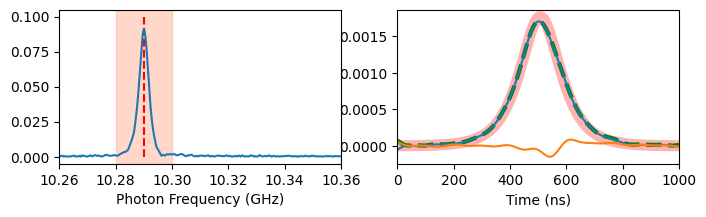

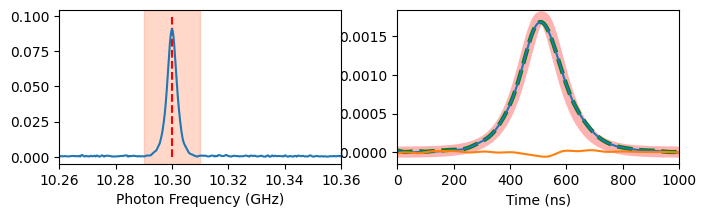

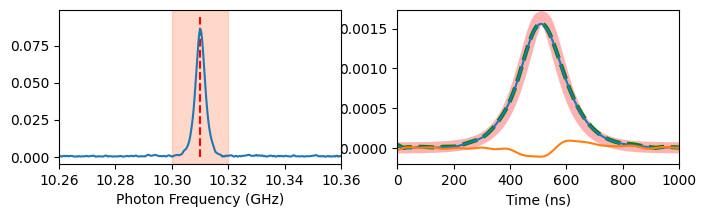

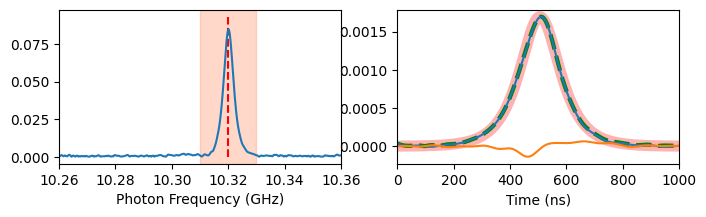

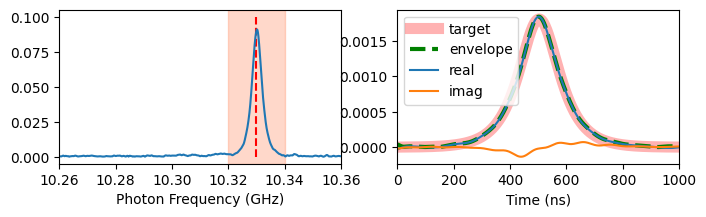

In [ ]:
passing_band = 0.01
duration=1500
cd = "CDY155"
data_path = f"D:\\K_Sunada\\result\\{cd}"

for k, v in result_dict.items():
    fig = plt.figure(figsize=(8, 2))
    ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    target_freq = v["target_freq"]
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    time = datadict["time"]["values"].ravel()
    waveform = datadict["waveform"]["values"].ravel()
    time, waveform = start_stop(time, waveform, 0, duration)
    phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    # print(readout_lo_freq-target_freq)
    xfft, fourier = fourier_tr_padding(time, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    ax.vlines(target_freq, 0, max(np.abs(fourier))*1.1, color="r", ls="--")
    ax.plot(photon_freq, np.abs(fourier))
    ax.axvspan(target_freq-passing_band, target_freq+passing_band, color="coral", alpha=0.3)
    ax.set_xlim(10.26, 10.36)
    ax.set_xlabel("Photon Frequency (GHz)")

    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        passing_band, 0.03, 0.1, 90) * np.exp(-1j*phase)
    res = fit_waveform(time, np.abs(signal), curve="sech", kappa=const)
    ax2.plot(time, res, "r-", lw=8, label="target", alpha=0.3)
    ax2.plot(time, np.abs(signal), "g--", lw=3, label="envelope")
    ax2.plot(time, signal.real, label="real")
    ax2.plot(time, signal.imag, label="imag")
    ax2.set_xlabel("Time (ns)")
    ax2.set_xlim(0, 1000)
    print(f"symmetry {IQ_sym_(signal, time)}, overlap {target_overlap(signal, time)}")
plt.legend()


# LO stability

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2023-10-04", acquire_time="102837")
time = np.unique(datadict["time"]["values"])
waveforms = datadict["waveform"]["values"]
target_freq = 10.51
for waveform in waveforms:
    signal = lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        0.005, 0.03, 0.5, 90)
    plt.plot(np.angle(signal))
# plt.ylim(-np.pi, -2); plt.xlim(100, 400)
plt.show()

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2023-09-04", acquire_time="155150")
time = np.unique(datadict["time"]["values"])
waveforms = datadict["waveform"]["values"]
target_freq = 10.51
for waveform in waveforms:
    signal = lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        0.005, 0.03, 0.5, 90)
    plt.plot(np.angle(signal))
plt.ylim(-np.pi, -2); plt.xlim(100, 400)
plt.show()

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2023-09-04", acquire_time="155457")
time = np.unique(datadict["time"]["values"])
waveforms = datadict["waveform"]["values"]
target_freq = 10.51
for waveform in waveforms:
    signal = lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        0.005, 0.03, 0.5, 90)
    plt.plot(np.angle(signal))
plt.ylim(-np.pi, -2); plt.xlim(100, 400)
plt.show()

In [ ]:
_, datadict = search_datadict_miyamura(data_path, "2023-09-04", acquire_time="155726")
time = np.unique(datadict["time"]["values"])
waveforms = datadict["waveform"]["values"]
target_freq = 10.51
for waveform in waveforms:
    signal = lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        0.005, 0.03, 0.5, 90)
    plt.plot(np.angle(signal))
plt.ylim(-np.pi, -2); plt.xlim(100, 400)
plt.show()

# Coherent state pulse mode

center:[2.20787141e-03 5.13448036e+02]
symmetry 0.998188823395506


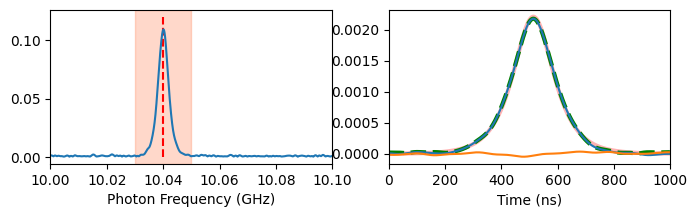

In [ ]:

fig = plt.figure(figsize=(8, 2))
ax = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)
target_freq = 10.04
_, datadict = search_datadict_miyamura(data_path, "2023-12-28", acquire_time="001327")
time = datadict["time"]["values"].ravel()
waveform = datadict["waveform"]["values"].ravel()
time, waveform = start_stop(time, waveform, 0, duration)
phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
# print(readout_lo_freq-target_freq)
xfft, fourier = fourier_tr_padding(time, waveform)
xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
photon_freq = readout_lo_freq + xfft
ax.vlines(target_freq, 0, max(np.abs(fourier))*1.1, color="r", ls="--")
ax.plot(photon_freq, np.abs(fourier))
ax.axvspan(target_freq-passing_band, target_freq+passing_band, color="coral", alpha=0.3)
ax.set_xlim(10.0, 10.1)
ax.set_xlabel("Photon Frequency (GHz)")

signal = 2 * lowpass(time, 
                    waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                    passing_band, 0.03, 0.1, 90) * np.exp(-1j*phase)
res = fit_waveform(time, np.abs(signal), curve="sech", kappa=const)
ax2.plot(time, res, "r-", lw=3, label="target", alpha=0.3)
ax2.plot(time, np.abs(signal), "g--", lw=3, label="envelope")
ax2.plot(time, signal.real, label="real")
ax2.plot(time, signal.imag, label="imag")
ax2.set_xlabel("Time (ns)")
ax2.set_xlim(0, 1000)
print(f"symmetry {IQ_sym_(signal, time)}")

### 10.04

amp 0.5, symmetry 0.9969884743474043
amp 0.51, symmetry 0.9976679978462245
amp 0.52, symmetry 0.9969677956568617
amp 0.53, symmetry 0.9964229901983458
amp 0.54, symmetry 0.9957954703127591
amp 0.55, symmetry 0.9835616036106739
amp 0.5599999999999999, symmetry 0.9092747535103238
amp 0.57, symmetry 0.9394792177011897
amp 0.58, symmetry 0.8602205409036179
amp 0.59, symmetry 0.8951291392691483
amp 0.6, symmetry 0.9686366049335406


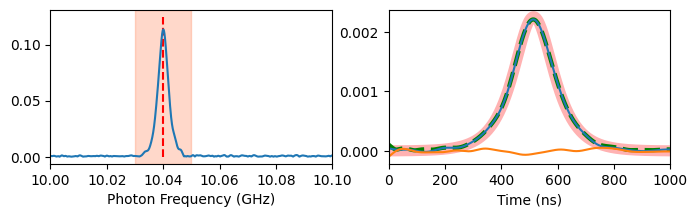

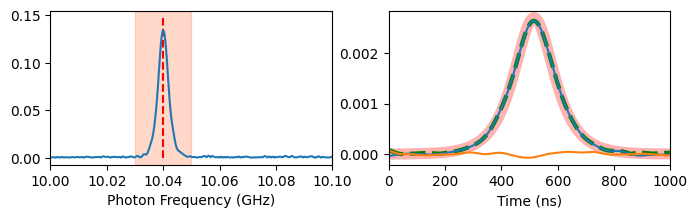

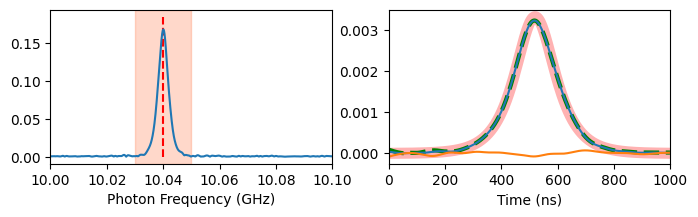

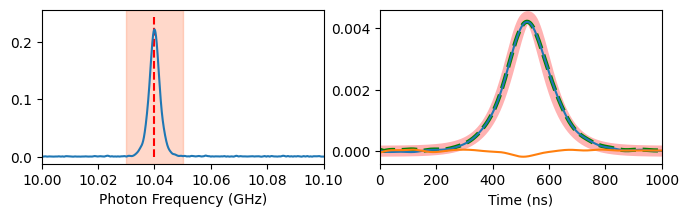

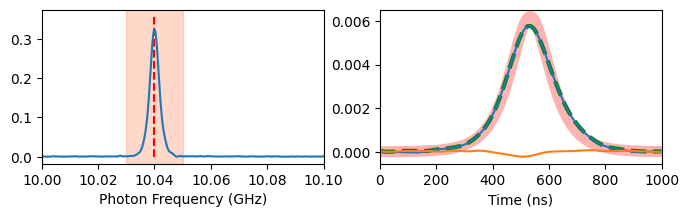

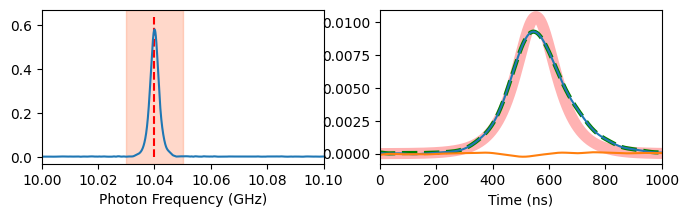

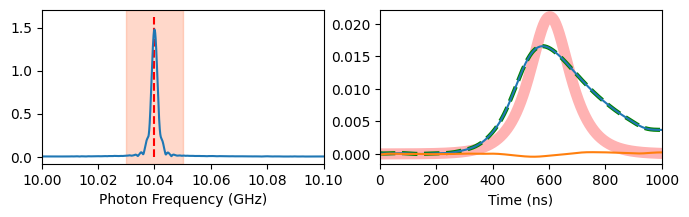

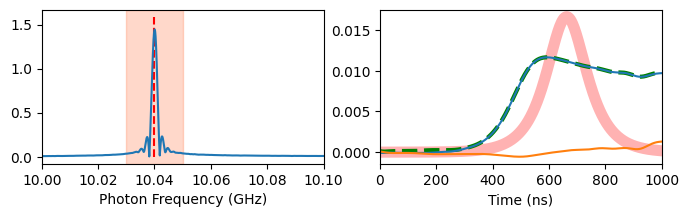

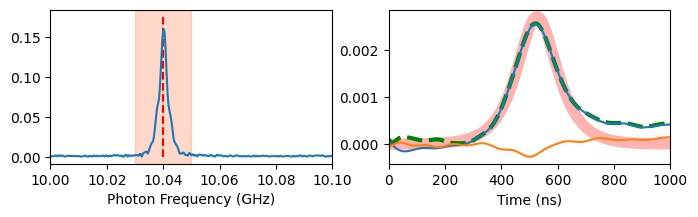

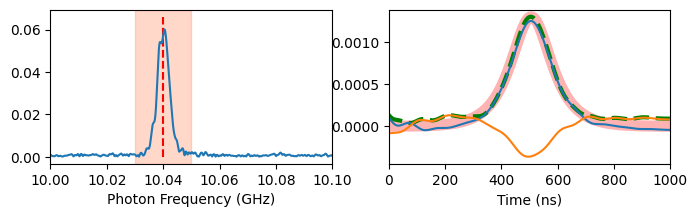

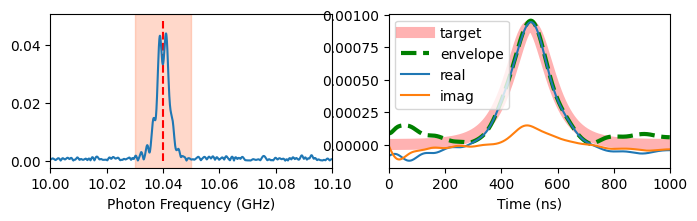

In [ ]:
target_freq = 10.04
_, datadict = search_datadict_miyamura(data_path, "2023-12-28", acquire_time="004238")
times = datadict["time"]["values"]
waveforms = datadict["waveform"]["values"]
JPA_amps = datadict["JPA_amp"]["values"]
for i, amp in enumerate(JPA_amps):
    fig = plt.figure(figsize=(8, 2))
    ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    time = times[i]
    waveform = waveforms[i]
    time, waveform = start_stop(time, waveform, 0, 1000)
    phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    # print(readout_lo_freq-target_freq)
    xfft, fourier = fourier_tr_padding(time, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    ax.vlines(target_freq, 0, max(np.abs(fourier))*1.1, color="r", ls="--")
    ax.plot(photon_freq, np.abs(fourier))
    ax.axvspan(target_freq-passing_band, target_freq+passing_band, color="coral", alpha=0.3)
    ax.set_xlim(10.0, 10.1)
    ax.set_xlabel("Photon Frequency (GHz)")

    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        passing_band, 0.03, 0.1, 90) * np.exp(-1j*phase)
    res = fit_waveform(time, np.abs(signal), curve="sech", kappa=const)
    ax2.plot(time, res, "r-", lw=8, label="target", alpha=0.3)
    ax2.plot(time, np.abs(signal), "g--", lw=3, label="envelope")
    ax2.plot(time, signal.real, label="real")
    ax2.plot(time, signal.imag, label="imag")
    ax2.set_xlabel("Time (ns)")
    ax2.set_xlim(0, 1000)
    print(f"amp {amp}, symmetry {IQ_sym_(signal, time)}")
plt.legend()

### 10.05

amp 0.55, symmetry 0.9971840832544125
amp 0.56, symmetry 0.9969944469750982
amp 0.5700000000000001, symmetry 0.9973783018890457
amp 0.5800000000000001, symmetry 0.9985016678234797
amp 0.5900000000000001, symmetry 0.9978524429687544
amp 0.6000000000000001, symmetry 0.9987722122375572
amp 0.61, symmetry 0.9980308599774763
amp 0.62, symmetry 0.9973295246788241
amp 0.63, symmetry 0.9957658009845848
amp 0.64, symmetry 0.9313401554813094
amp 0.65, symmetry 0.9462507418991843


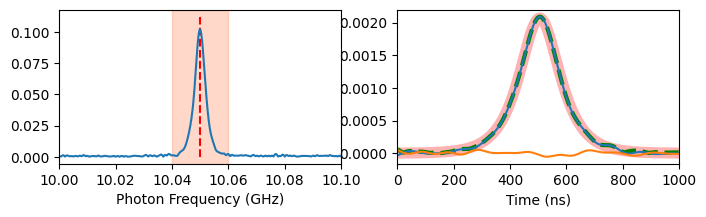

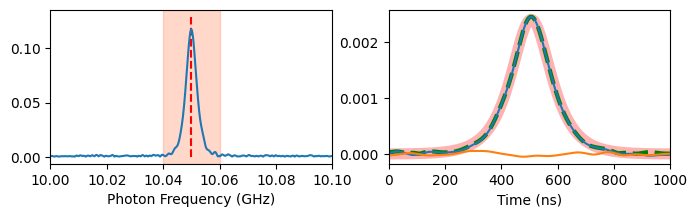

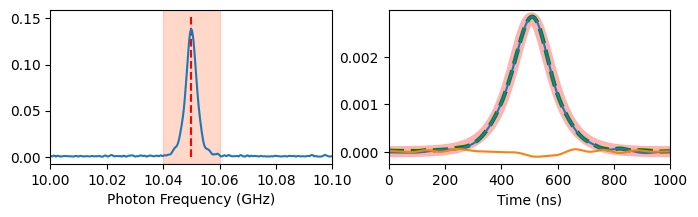

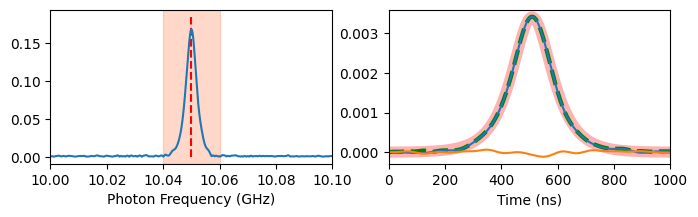

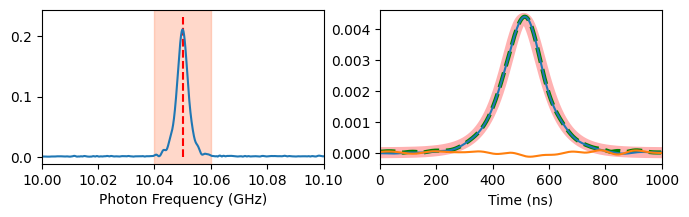

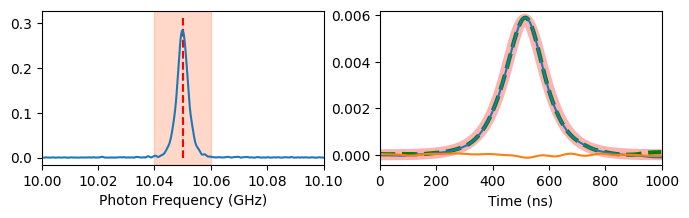

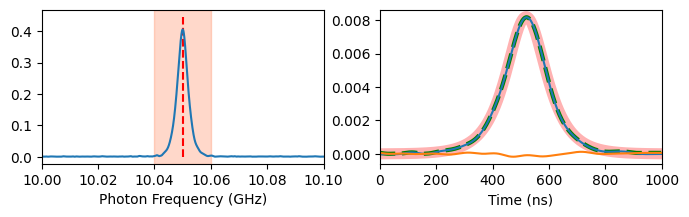

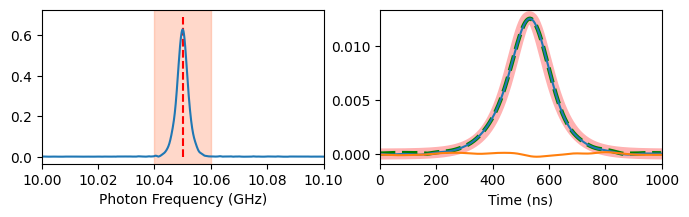

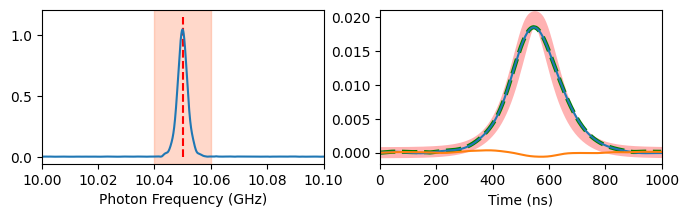

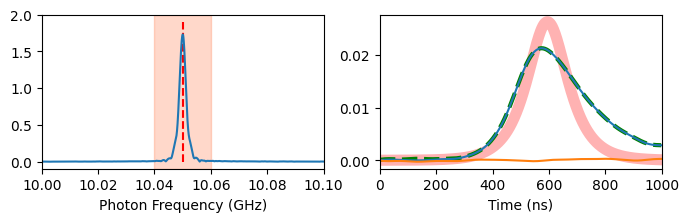

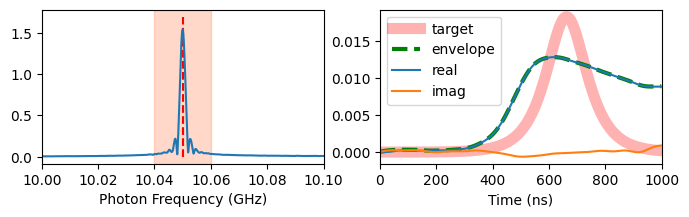

In [ ]:
target_freq = 10.05
_, datadict = search_datadict_miyamura(data_path, "2023-12-28", acquire_time="005245")
times = datadict["time"]["values"]
waveforms = datadict["waveform"]["values"]
JPA_amps = datadict["JPA_amp"]["values"]
for i, amp in enumerate(JPA_amps):
    fig = plt.figure(figsize=(8, 2))
    ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    time = times[i]
    waveform = waveforms[i]
    time, waveform = start_stop(time, waveform, 0, 1000)
    phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    # print(readout_lo_freq-target_freq)
    xfft, fourier = fourier_tr_padding(time, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    ax.vlines(target_freq, 0, max(np.abs(fourier))*1.1, color="r", ls="--")
    ax.plot(photon_freq, np.abs(fourier))
    ax.axvspan(target_freq-passing_band, target_freq+passing_band, color="coral", alpha=0.3)
    ax.set_xlim(10.0, 10.1)
    ax.set_xlabel("Photon Frequency (GHz)")

    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        passing_band, 0.03, 0.1, 90) * np.exp(-1j*phase)
    res = fit_waveform(time, np.abs(signal), curve="sech", kappa=const)
    ax2.plot(time, res, "r-", lw=8, label="target", alpha=0.3)
    ax2.plot(time, np.abs(signal), "g--", lw=3, label="envelope")
    ax2.plot(time, signal.real, label="real")
    ax2.plot(time, signal.imag, label="imag")
    ax2.set_xlabel("Time (ns)")
    ax2.set_xlim(0, 1000)
    print(f"amp {amp}, symmetry {IQ_sym_(signal, time)}")
plt.legend()

### 10.06

amp 0.55, symmetry 0.9975181732560175
amp 0.56, symmetry 0.9964590254110225
amp 0.5700000000000001, symmetry 0.9936484711328262
amp 0.5800000000000001, symmetry 0.9927316139409624
amp 0.5900000000000001, symmetry 0.9895183702601917
amp 0.6000000000000001, symmetry 0.9716516340784715
amp 0.61, symmetry 0.9262320663926062
amp 0.62, symmetry 0.9236732626579393
amp 0.63, symmetry 0.9141109628838205
amp 0.64, symmetry 0.9522369220397634
amp 0.65, symmetry 0.9738082374737108


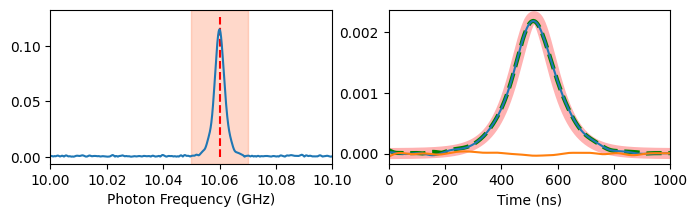

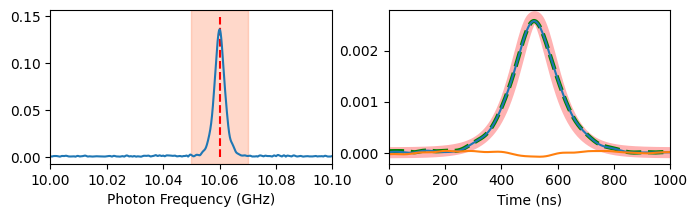

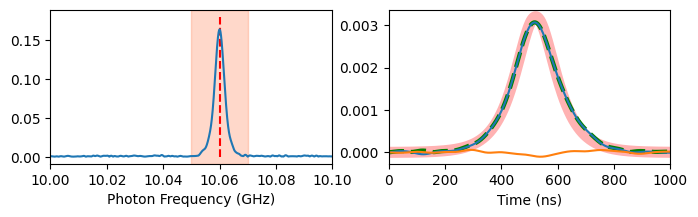

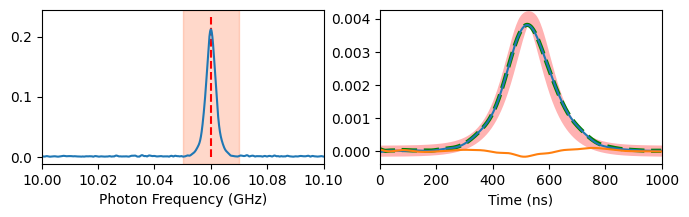

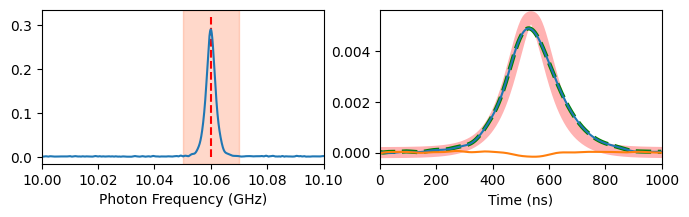

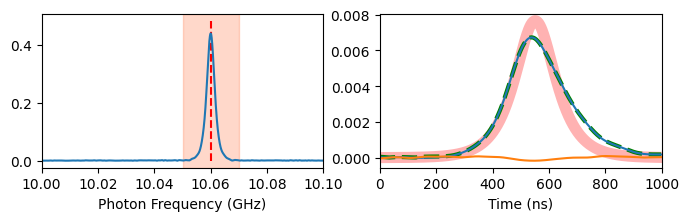

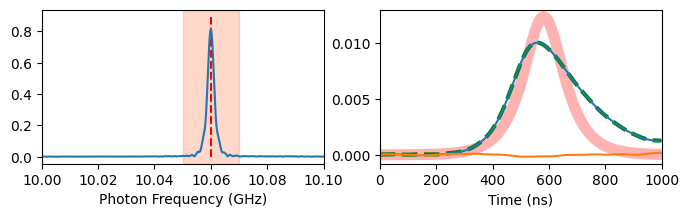

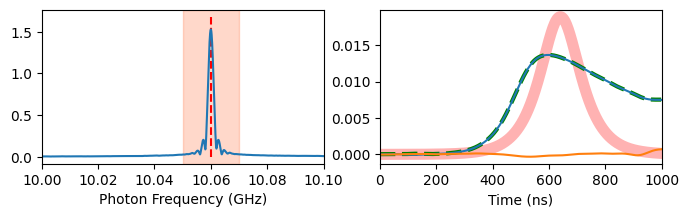

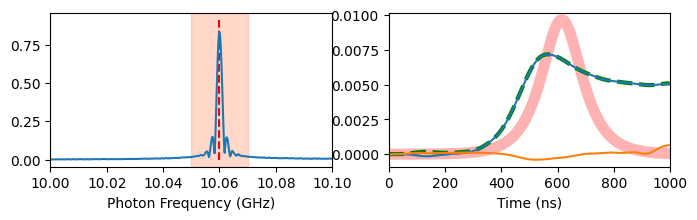

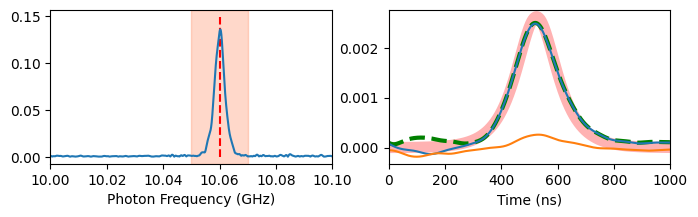

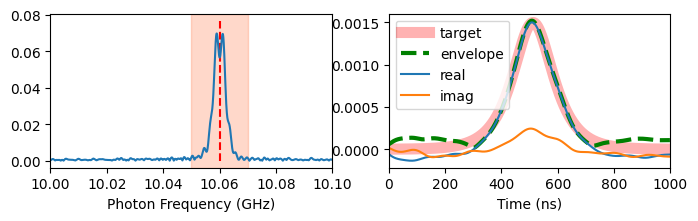

In [ ]:
target_freq = 10.06
_, datadict = search_datadict_miyamura(data_path, "2023-12-28", acquire_time="005552")
times = datadict["time"]["values"]
waveforms = datadict["waveform"]["values"]
JPA_amps = datadict["JPA_amp"]["values"]
for i, amp in enumerate(JPA_amps):
    fig = plt.figure(figsize=(8, 2))
    ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    time = times[i]
    waveform = waveforms[i]
    time, waveform = start_stop(time, waveform, 0, 1000)
    phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    # print(readout_lo_freq-target_freq)
    xfft, fourier = fourier_tr_padding(time, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    ax.vlines(target_freq, 0, max(np.abs(fourier))*1.1, color="r", ls="--")
    ax.plot(photon_freq, np.abs(fourier))
    ax.axvspan(target_freq-passing_band, target_freq+passing_band, color="coral", alpha=0.3)
    ax.set_xlim(10.0, 10.1)
    ax.set_xlabel("Photon Frequency (GHz)")

    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        passing_band, 0.03, 0.1, 90) * np.exp(-1j*phase)
    res = fit_waveform(time, np.abs(signal), curve="sech", kappa=const)
    ax2.plot(time, res, "r-", lw=8, label="target", alpha=0.3)
    ax2.plot(time, np.abs(signal), "g--", lw=3, label="envelope")
    ax2.plot(time, signal.real, label="real")
    ax2.plot(time, signal.imag, label="imag")
    ax2.set_xlabel("Time (ns)")
    ax2.set_xlim(0, 1000)
    print(f"amp {amp}, symmetry {IQ_sym_(signal, time)}")
plt.legend()

### 10.07

amp 0.55, symmetry 0.9971219687644046
amp 0.56, symmetry 0.9952034656616398
amp 0.5700000000000001, symmetry 0.9964167986678153
amp 0.5800000000000001, symmetry 0.9945825122879584
amp 0.5900000000000001, symmetry 0.9982684585165352
amp 0.6000000000000001, symmetry 0.9970198681267761
amp 0.61, symmetry 0.9973449988084153
amp 0.62, symmetry 0.9953815612859785
amp 0.63, symmetry 0.9952403349336283
amp 0.64, symmetry 0.9936042159209576
amp 0.65, symmetry 0.984918296871761


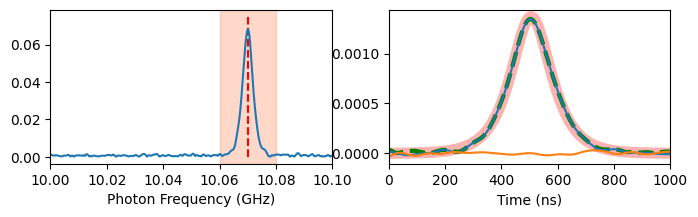

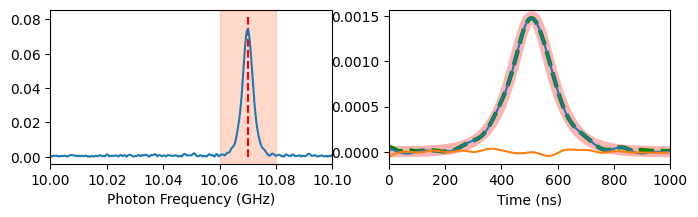

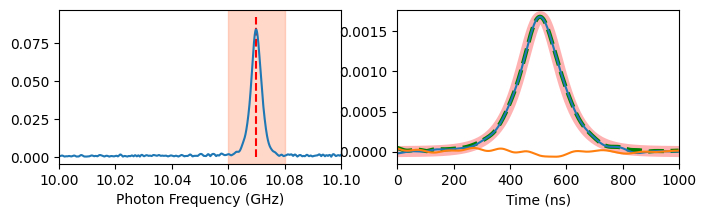

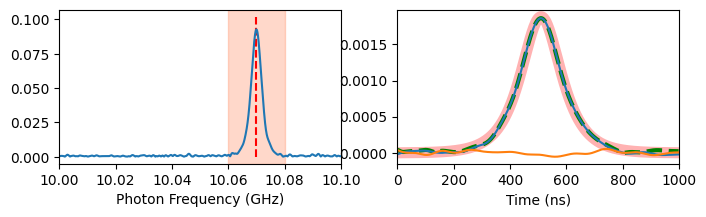

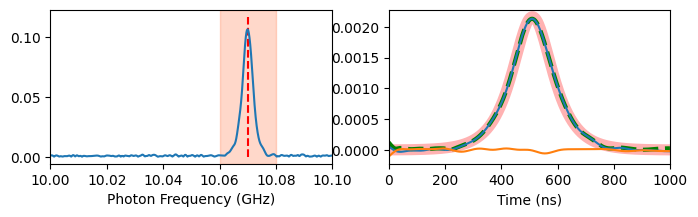

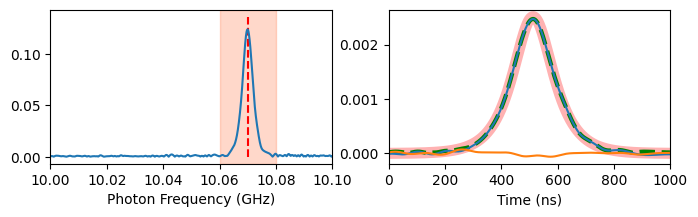

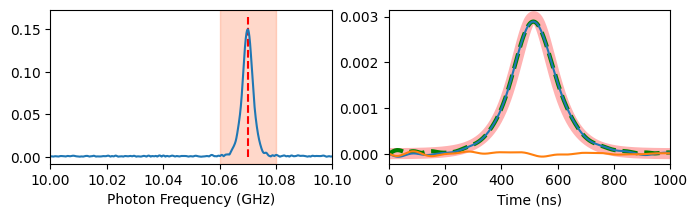

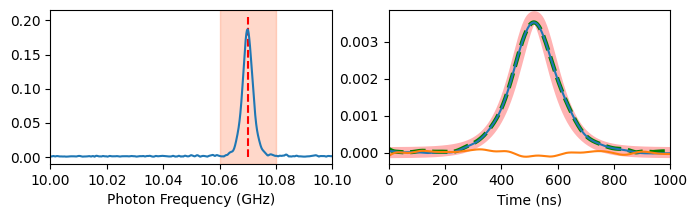

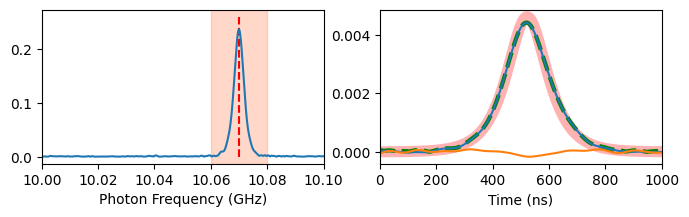

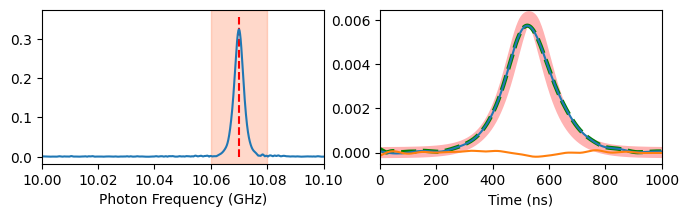

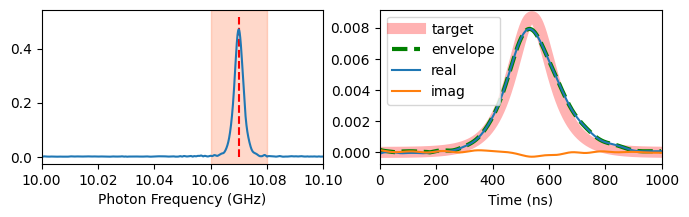

In [ ]:
target_freq = 10.07
_, datadict = search_datadict_miyamura(data_path, "2023-12-28", acquire_time="005744")
times = datadict["time"]["values"]
waveforms = datadict["waveform"]["values"]
JPA_amps = datadict["JPA_amp"]["values"]
for i, amp in enumerate(JPA_amps):
    fig = plt.figure(figsize=(8, 2))
    ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    time = times[i]
    waveform = waveforms[i]
    time, waveform = start_stop(time, waveform, 0, 1000)
    phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    # print(readout_lo_freq-target_freq)
    xfft, fourier = fourier_tr_padding(time, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    ax.vlines(target_freq, 0, max(np.abs(fourier))*1.1, color="r", ls="--")
    ax.plot(photon_freq, np.abs(fourier))
    ax.axvspan(target_freq-passing_band, target_freq+passing_band, color="coral", alpha=0.3)
    ax.set_xlim(10.0, 10.1)
    ax.set_xlabel("Photon Frequency (GHz)")

    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        passing_band, 0.03, 0.1, 90) * np.exp(-1j*phase)
    res = fit_waveform(time, np.abs(signal), curve="sech", kappa=const)
    ax2.plot(time, res, "r-", lw=8, label="target", alpha=0.3)
    ax2.plot(time, np.abs(signal), "g--", lw=3, label="envelope")
    ax2.plot(time, signal.real, label="real")
    ax2.plot(time, signal.imag, label="imag")
    ax2.set_xlabel("Time (ns)")
    ax2.set_xlim(0, 1000)
    print(f"amp {amp}, symmetry {IQ_sym_(signal, time)}")
plt.legend()

### 10.08

amp 0.6, symmetry 0.9964584690117618
amp 0.61, symmetry 0.9926852080076233
amp 0.62, symmetry 0.9951421570857001
amp 0.63, symmetry 0.9949032395013542
amp 0.64, symmetry 0.9942710200755973
amp 0.6499999999999999, symmetry 0.99663800608702
amp 0.6599999999999999, symmetry 0.9956422925930051
amp 0.6699999999999999, symmetry 0.9932125779154234
amp 0.6799999999999999, symmetry 0.9941676463789725
amp 0.69, symmetry 0.993065067384239
amp 0.7, symmetry 0.9918938090714503


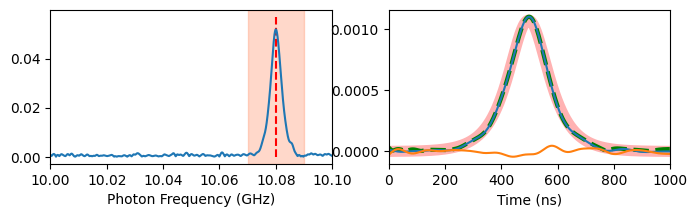

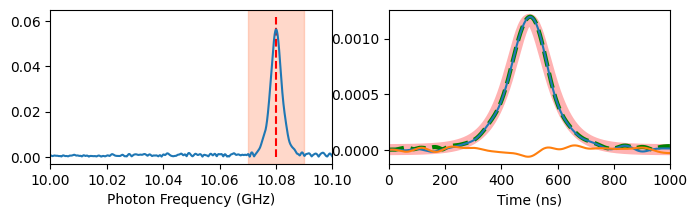

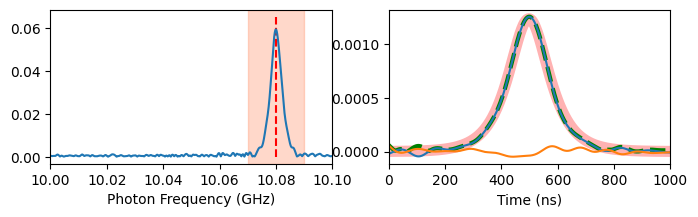

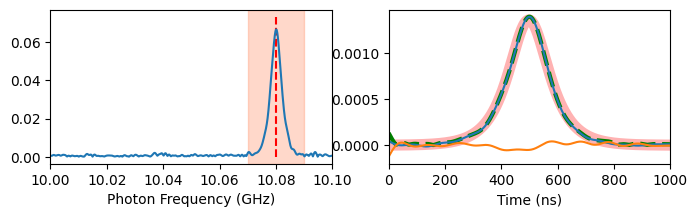

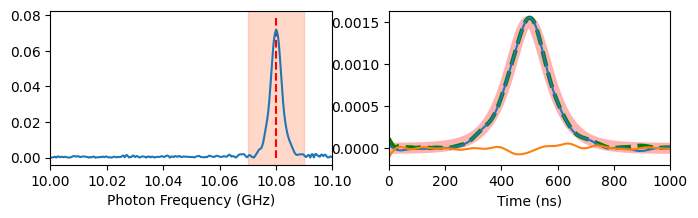

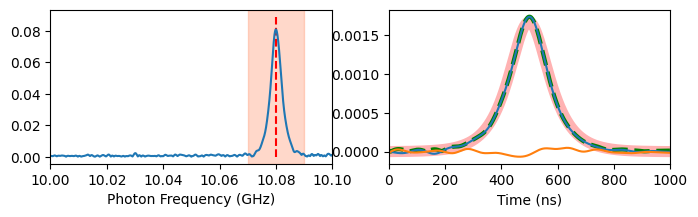

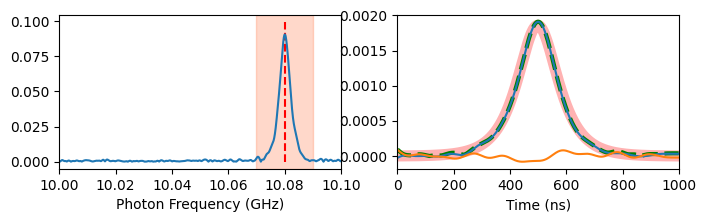

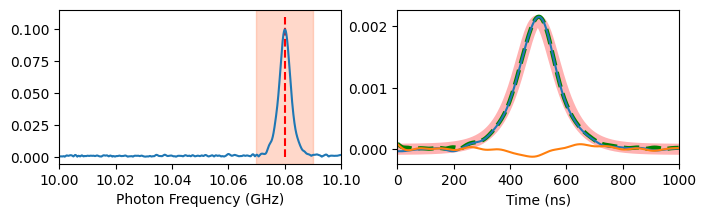

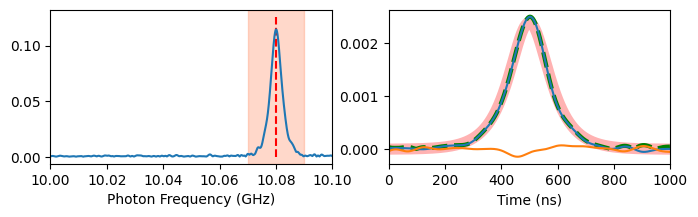

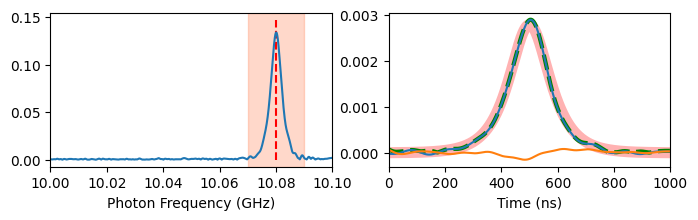

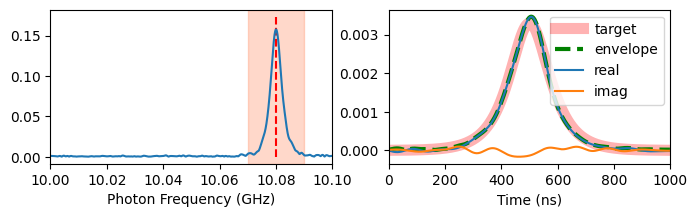

In [ ]:
target_freq = 10.08
_, datadict = search_datadict_miyamura(data_path, "2023-12-28", acquire_time="005933")
times = datadict["time"]["values"]
waveforms = datadict["waveform"]["values"]
JPA_amps = datadict["JPA_amp"]["values"]
for i, amp in enumerate(JPA_amps):
    fig = plt.figure(figsize=(8, 2))
    ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    time = times[i]
    waveform = waveforms[i]
    time, waveform = start_stop(time, waveform, 0, 1000)
    phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    # print(readout_lo_freq-target_freq)
    xfft, fourier = fourier_tr_padding(time, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    ax.vlines(target_freq, 0, max(np.abs(fourier))*1.1, color="r", ls="--")
    ax.plot(photon_freq, np.abs(fourier))
    ax.axvspan(target_freq-passing_band, target_freq+passing_band, color="coral", alpha=0.3)
    ax.set_xlim(10.0, 10.1)
    ax.set_xlabel("Photon Frequency (GHz)")

    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        passing_band, 0.03, 0.1, 90) * np.exp(-1j*phase)
    res = fit_waveform(time, np.abs(signal), curve="sech", kappa=const)
    ax2.plot(time, res, "r-", lw=8, label="target", alpha=0.3)
    ax2.plot(time, np.abs(signal), "g--", lw=3, label="envelope")
    ax2.plot(time, signal.real, label="real")
    ax2.plot(time, signal.imag, label="imag")
    ax2.set_xlabel("Time (ns)")
    ax2.set_xlim(0, 1000)
    print(f"amp {amp}, symmetry {IQ_sym_(signal, time)}")
plt.legend()

In [ ]:
1 / 50.5 * 1e3 / 2 / np.pi

In [ ]:
1 / 4 / 2 / np.pi * 1e3